### 자동미분

- backward()로 미분값 계산

In [1]:
import torch

torch.__version__

'2.12.0+cu126'

In [3]:
# 이전 미분계산
x = torch.tensor(2.0, requires_grad=True)

z = x ** 2
y = z * 3

y

tensor(12., grad_fn=<MulBackward0>)

- 최종결과 y에 . backward() 메서드 호출 : 파이토치가 계산그래프를 역전파해서 각 텐서의 미분값을 자동계산
- .grad 속성에 저장

In [6]:
# backward()
x = torch.tensor(2.0, requires_grad=True)

# 계산그래프 생성연산
z = x ** 2
y = z * 3

# y를 x에 대해 미분
y.backward()

# x의 미분값(기울기)
# y에 대한 x의 기울기
print(f'x의 미분값(dy/dx) : {x.grad}')

x의 미분값(dy/dx) : 12.0


### 경사하강법

- y = wx + b 의 값을 구하는 모델 학습
- w : 가중치(weight)
- b : 절편(bias) 또는 편향

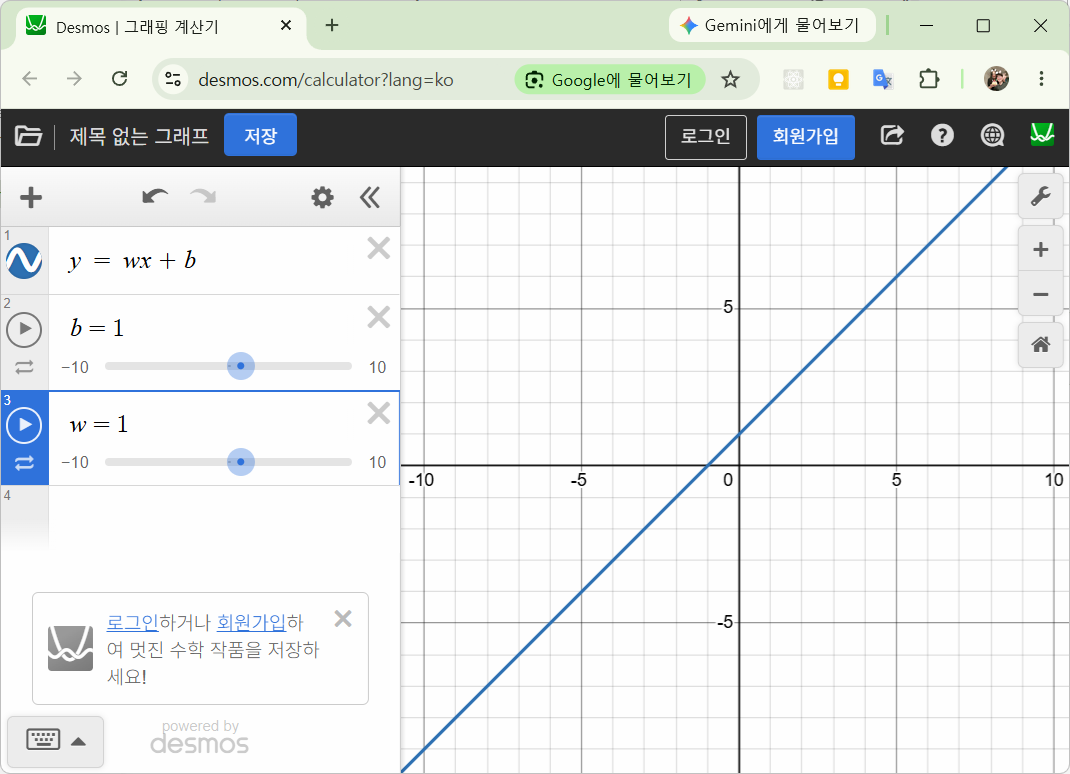

In [ ]:
# 학습할 가중치, 절편(편향) 정의
# w, b 의 미분값을 계산하기 때문 requires_grad=True로
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# 입력데이터, 정답데이터
x = torch.tensor(2.0)
y_true = torch.tensor(5.0)  # 실제값. 모델이 정답이 틀려야 학습가능

# 순전파 : 모델의 예측값 계산
y_pred = w * x + b
print(y_pred)

# 손실(Loss) 계산
loss = (y_pred - y_true)**2

print(f'예측값 : {y_pred.item()}')
print(f'손실 : {loss.item()}')

# 역전파 : 손실에 대해 w와 b의 미분값 계산
loss.backward()

# w와 b의 미분값 확인
# 기울기를 이용해서 w와 b를 업데이트하고 손실을 줄여나갈 수 있음
print(f'w의 미분값 : {w.grad}')
print(f'b의 미분값 : {b.grad}')

tensor(3., grad_fn=<AddBackward0>)
예측값 : 3.0
손실 : 4.0
w의 미분값 : -8.0
b의 미분값 : -4.0


#### 손실함수

오차를 숫자로 계산
- MSE(평균제곱오차) : 예측값을 실제값으로 뺀 다음 제곱승
- MAE(평균절대오차) : 예측값과 실제값을 뺀뒤 절대값의 

#### 학습률

- Learning rate : 얼마나 조금씩 수정할지 결정하는 값
- 0.001 ~ 0.1 사이로 사용

In [19]:
# 학습데이터
# 공부시간 / 시험점수
hours = torch.tensor([
    [1.],
    [2.],
    [3.],
    [4.],
    [5.],
])

scores = torch.tensor([
    [52.],
    [60.],
    [68.],
    [76.],
    [84.],    
])

## 2. 학습학 값 생성
# 학습할 파라미터
w = torch.tensor([[1.0]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

## 3. 학습률 지정
learning_rate = 0.03

## 4. 반복학습 수행
for epoch in range(1001):
    
    ## 5. 예측값 계산(행렬곱)
    y_pred = hours @ w + b

    ## 6. 손실함수(MSE)
    loss = torch.mean((y_pred - scores) ** 2)

    ## 기존 미분값 초기화
    # 매번학습전에 grad를 0으로 초기화
    # 안하면 잘못된 값 학습
    if w.grad is not None:
        w.grad.zero_()

    if b.grad is not None:
        w.grad.zero_()
    
    ## 8. 역전파 - 자동미분 계산
    loss.backward()

    ## 9. 경사하강법 - w, b업데이트
    with torch.no_grad(): # 자동미분 엔진을 비활성화해서 필요메모리를 줄이고 연산속도 증가
        # 업데이트 과정에서 계산 그래프를 기록하지 않기 위해서
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 100번마다 출력
    if epoch % 100 == 0:
        print(f'epoch={epoch:4d} loss={loss.item():.4f} w={w.item():.4f} b={b.item():.4f}')

# 최종결과
print('\n최종학습결과')
print(f'기울기 w = {w.item():.4f}')
print(f'절편 b = {b.item():.4f}')

## 10. 테스트 수행
test_hours = torch.tensor([
    [.6],
    [.7],
    [.8]
])

with torch.no_grad():
    pred_scores = test_hours @ w + b

print('\n예측결과')
for h, s in zip(test_hours, pred_scores):
    print(f'{h.item():.0f}시간 공부 -> 예상점수 {s.item():.2f}')

epoch=   0 loss=4323.0000 w=13.5400 b=3.9000
epoch= 100 loss=0.0363 w=7.9368 b=44.0472
epoch= 200 loss=0.0000 w=7.9972 b=44.0125
epoch= 300 loss=0.0000 w=8.0001 b=43.9996
epoch= 400 loss=0.0000 w=8.0000 b=44.0000
epoch= 500 loss=0.0000 w=8.0000 b=44.0000
epoch= 600 loss=0.0000 w=8.0000 b=44.0000
epoch= 700 loss=0.0000 w=8.0000 b=44.0000
epoch= 800 loss=0.0000 w=8.0000 b=44.0000
epoch= 900 loss=0.0000 w=8.0000 b=44.0000
epoch=1000 loss=0.0000 w=8.0000 b=44.0000

최종학습결과
기울기 w = 8.0000
절편 b = 44.0000

예측결과
1시간 공부 -> 예상점수 48.80
1시간 공부 -> 예상점수 49.60
1시간 공부 -> 예상점수 50.40


- learning_rate를 계속 변경하면서 최적의 모델 찾기
- 0.1, 0.01, 0.001 반복테스트 후
- 0.03이 가장 최적의 lr임을 확인

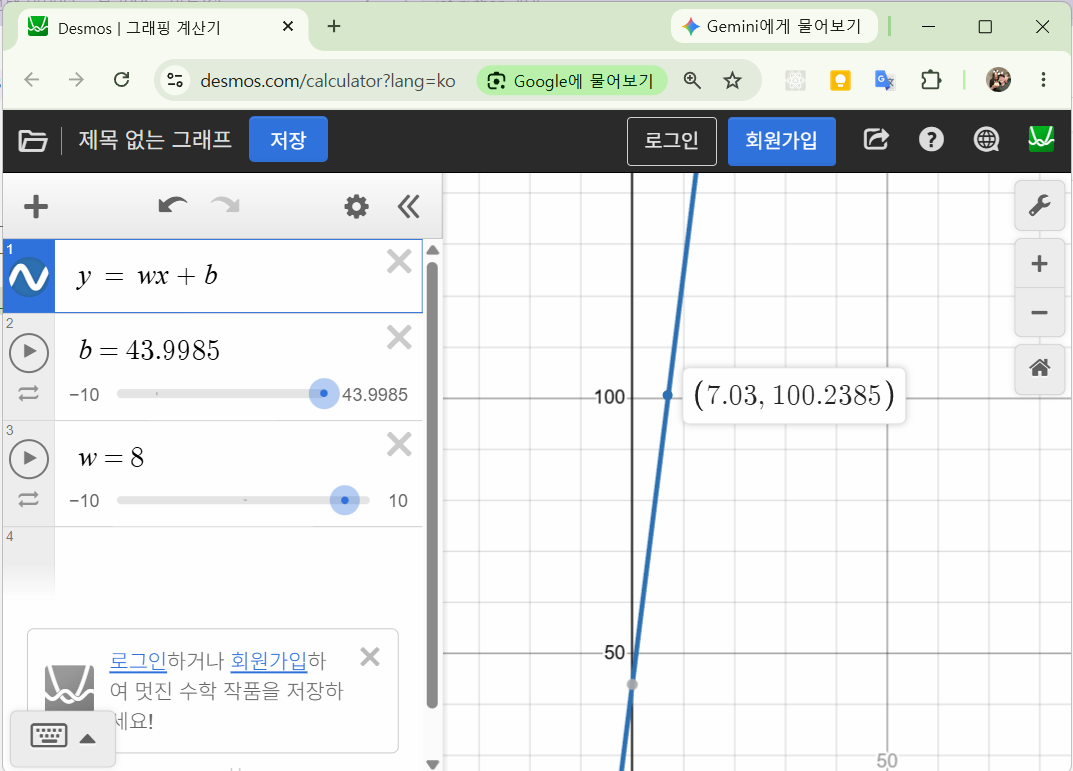

In [ ]:
#### 정리

- 일반 프로그래밍 : 입력값, 가중치, 젏편을 입력해서, 출력값을 리턴하는 프로그램 개발
- 인공지능 프로그래밍 : 입력값, 출력값을 입력해서 가중치, 절편 등을 구하는 모델을 개발

##### 퍼셉트론

- 다수의 신호를 입력, 하나이 신호로 출력하는 모델
- 인간의 뉴런(신경세포)가 다른 뉴런의 신호를 받아 활성화/비활성화되는 것을 모방

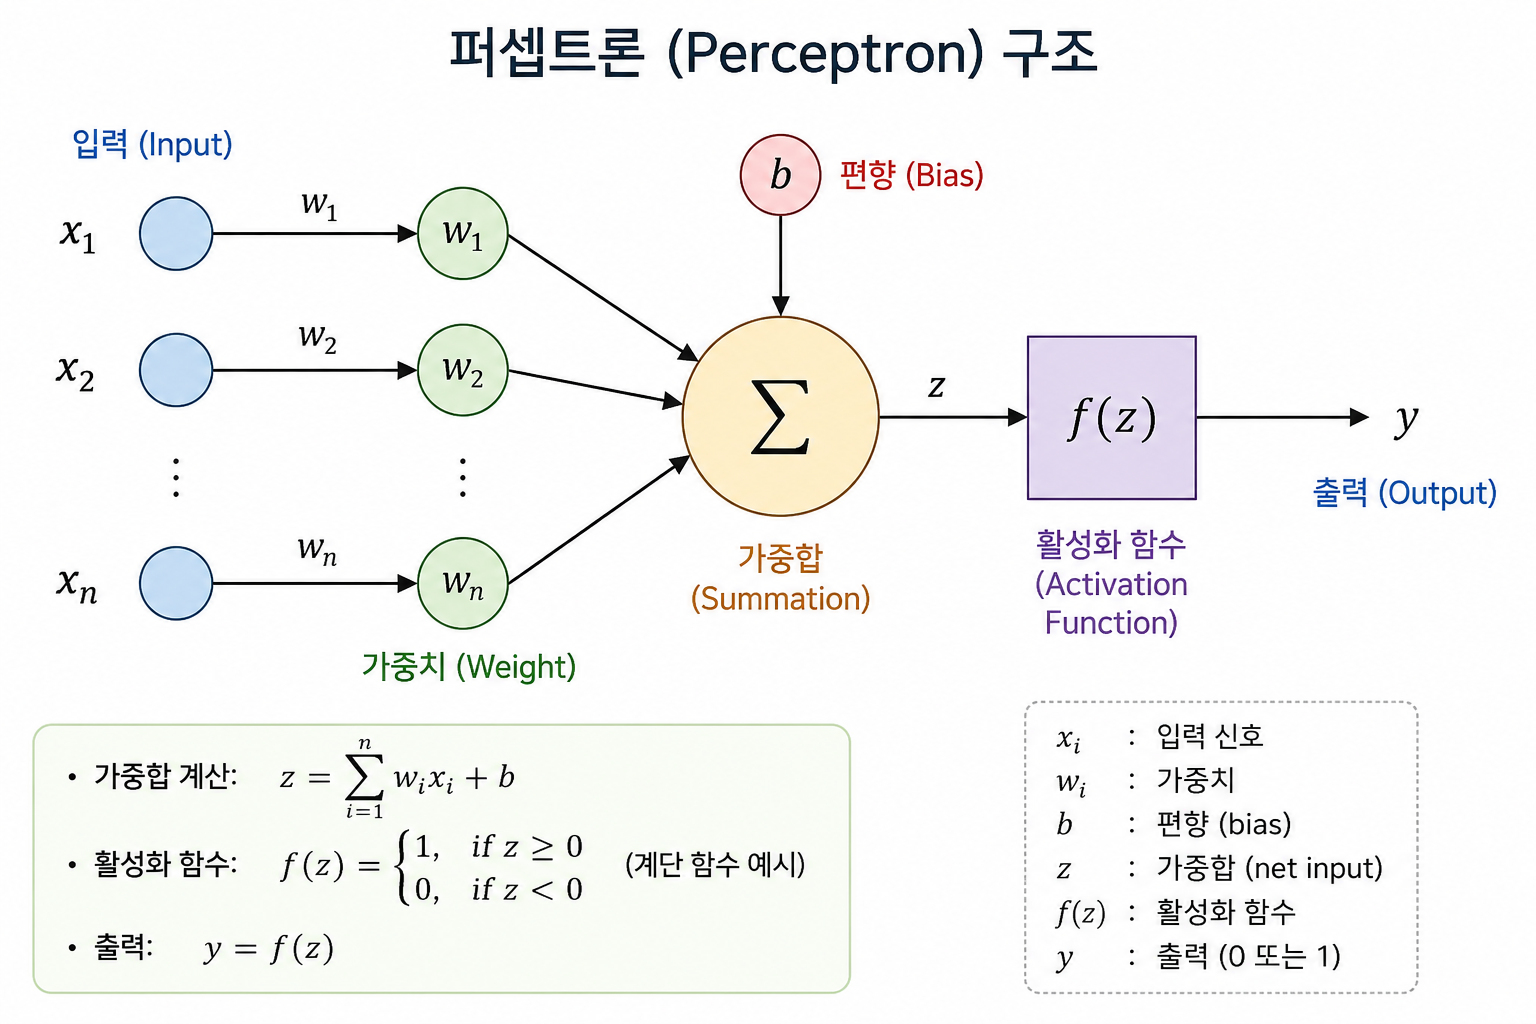

#### 다중퍼셉트론

- 단일 퍼셉트론의 한계를 극복하기 위해 등장. 퍼셉트론을 여러개 쌓아올린 구조
- 입력츨, 은닉층, 출력층으로 구분

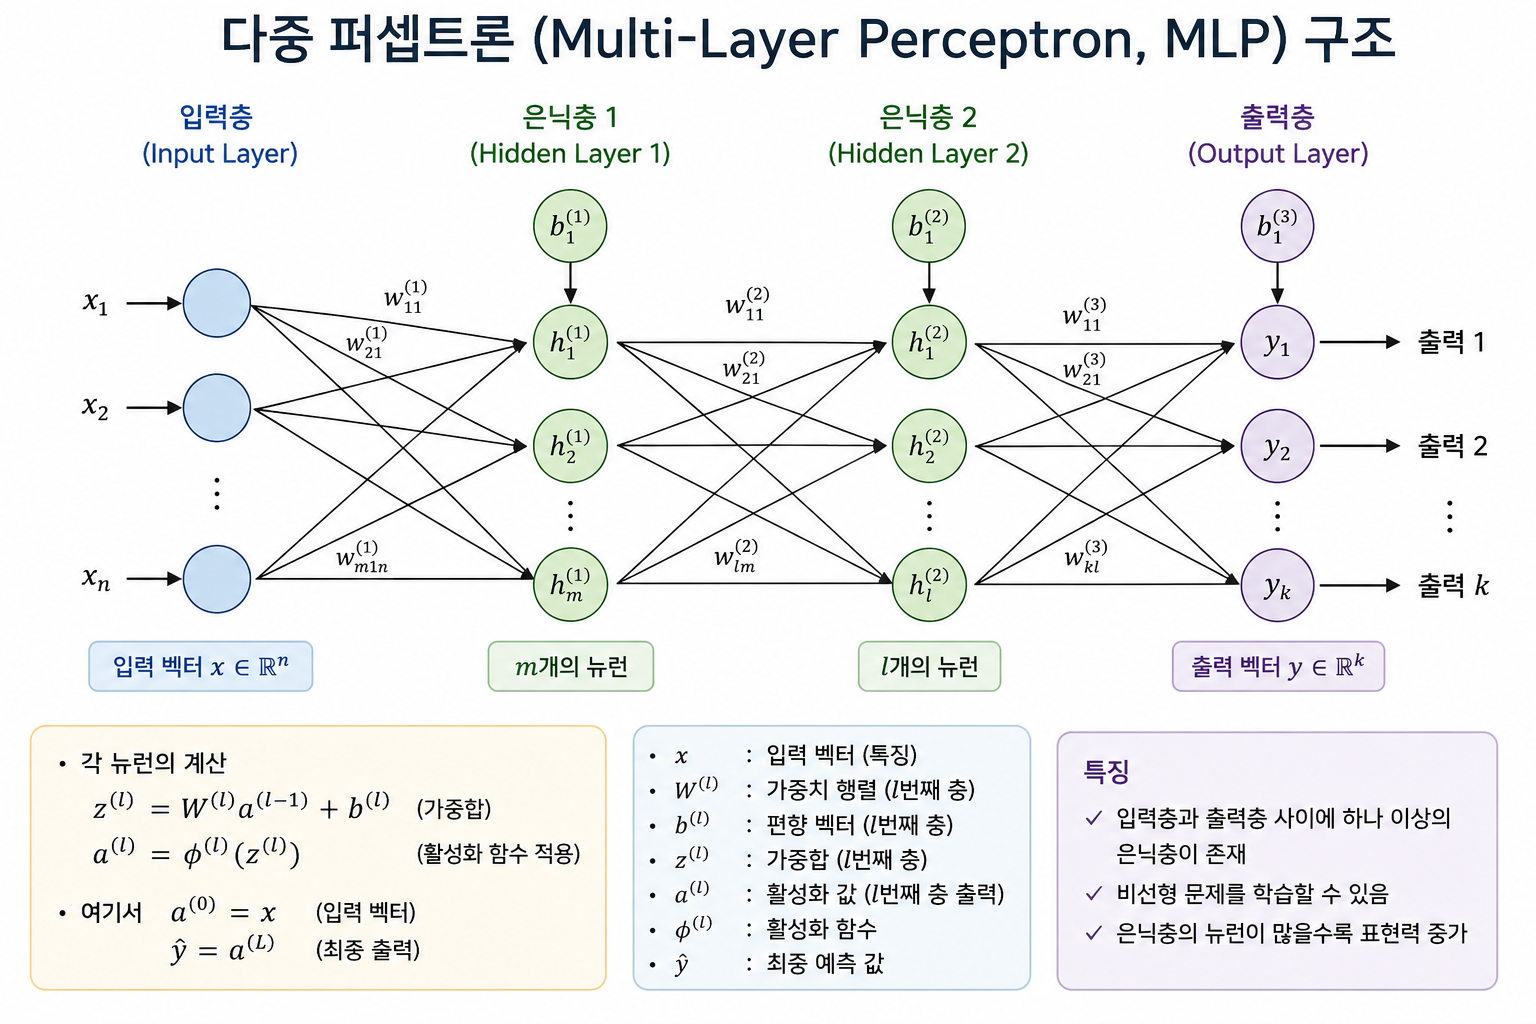

#### 활성화함수
- 출력을 어떻게 변형할지 결정하는 맣수
- Sigmoid, Tanh, `ReLU`, Softmax

In [28]:
# 필요라이브러리 추가
import torch
import torch.nn as nn     # 신경망 모듈
import torch.optim as optim    # 손실함수 최적화알고리즘 모듈

# y = 2x + 1
# 1. 데이터 준비
# 결과를 유사하게 만들 랜덤시드 설정
torch.manual_seed(42)

w_true = 2.0
b_true = 1.0

# 100개의 랜덤값 x를 생성
X = torch.randn(100, 1) * 10  # (100, 1)

# y값 생성 : y = 2x + 1 + noise
Y = w_true * X + b_true

# 2. 다중퍼셉트론 모델 설계
class MLPRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # 입력 1 -> 1st 은닉층 16개
            nn.Linear(in_features=1, out_features=16),
            # 활성화 함수
            nn.ReLU(),
            # 1st 은닉층 16개 -> 2nd 은닉층 8개
            # 위의 출력층에서 8개로 분리되었는데 현재 입력층에서 8개로 입력받지 않으면 오류발생!
            nn.Linear(in_features=16, out_features=8),
            nn.ReLU(),
            # 2nd 은닉층 8개 -> 출력층 1개
            nn.Linear(in_features=8, out_features=1)
        )
        
    def forward(self, x):
        return self.model(x)
    
# 3. 모델 생성
model = MLPRegression()

# 4. 손실함수
loss_fn = nn.MSELoss()
# 5. 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 6. 학습
num_epochs = 2000

for epoch in range(num_epochs):
    # 1) 순전파
    y_pred = model(X)

    # 2) 손실 계산
    loss = loss_fn(y_pred, Y)

    # 3) 기존 기울기 최소화
    optimizer.zero_grad()

    # 4) 역전파
    loss.backward()

    # 5) 파라미터 업데이트 -> 
    optimizer.step()

    # 100번마다 출력
    if (epoch + 1) % 100 == 0:
        print(
            f'epoch={epoch + 1:4d} '
            f'loss={loss.item():.6f}'
        )

# 7. 예측 테스트
test_x = torch.tensor([[5.0],
                       [10.0],
                       [15.0]])

with torch.no_grad():
    test_y_pred = model(test_x)

print('\n=== 예측 결과 ===')
for x, y in zip(test_x, test_y_pred):
    print(f'x = {x.item():.1f} -> 예측 y = {y.item():.4f}')

# 8. 실제 정답과 비교
print('\n=== 실제 정답 ===')
for x in test_x:
    true_y = w_true * x + b_true
    print(f'x = {x.item():.1f} -> 실제 y = {true_y.item():.4f}')

epoch= 100 loss=0.162333
epoch= 200 loss=0.051195
epoch= 300 loss=0.013114
epoch= 400 loss=0.003995
epoch= 500 loss=0.002230
epoch= 600 loss=0.001695
epoch= 700 loss=0.001380
epoch= 800 loss=0.001158
epoch= 900 loss=0.000993
epoch=1000 loss=0.000868
epoch=1100 loss=0.000767
epoch=1200 loss=0.000688
epoch=1300 loss=0.000620
epoch=1400 loss=0.000558
epoch=1500 loss=0.000500
epoch=1600 loss=0.000447
epoch=1700 loss=0.000397
epoch=1800 loss=0.000351
epoch=1900 loss=0.000308
epoch=2000 loss=0.000269

=== 예측 결과 ===
x = 5.0 -> 예측 y = 10.9959
x = 10.0 -> 예측 y = 20.9984
x = 15.0 -> 예측 y = 31.0008

=== 실제 정답 ===
x = 5.0 -> 실제 y = 11.0000
x = 10.0 -> 실제 y = 21.0000
x = 15.0 -> 실제 y = 31.0000
